# Impact on the photometry at camera level of AOCS jitter

$\textbf{Goals}$

Test the impact and behavior of spacecraft Attitude and Orbital Control System (AOCS) jitter on camera level. 

$\textbf{Context}$

In order to achieve the required noise budget at mission level, the PMC has defined Mean Pointing Error and Relative Pointing Error requirements at camera level. In the high frequency range ($f \gg 0.04$Hz), the dominant contribution results from the performance of the attitude and orbit control system of the S/C (jitter).

$\textbf{Simulations}$

To test the impact of jitter it should be enough to have several short-term simulations (1 day long), for 24 N-CAMs and several quarters. Specifically one simulation with fast jitter (8 Hz), and one simulation without jitter (only white noise jitter) shall be compared to tell whether a jitter correction on-ground is mandatory or not. 
Prime have delivered a high frequency jitter simulations for one N-Cam w.r.t. to F2-Cam with a cadence of 8 Hz and duration of 27h. We shall investigate if this simulation can be cycled to the remaining cameras and how this might impact the forthcoming analysis.

As a baseline, we keep on-ground processing as an option for WC of the impact of jitter.

$\textbf{Data analysis}$

In [5]:
%matplotlib inline

import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
from scipy.interpolate import make_interp_spline
from scipy.ndimage import median_filter
from scipy import constants as c

from platosim.noise import *
from platosim.plot import *

# Handle warnings
import warnings
warnings.filterwarnings('ignore')

### Functions

In [2]:
def matrixMisalignment(x, y, z):   
    r11 = + np.cos(x)*np.cos(z) - np.sin(x)*np.sin(z)*np.sin(y)
    r12 = - np.cos(x)*np.sin(z) - np.sin(x)*np.cos(z)*np.cos(y)
    r13 = + np.sin(x)*np.sin(z)
    r21 = + np.sin(x)*np.cos(z) + np.cos(x)*np.sin(z)*np.cos(y)
    r22 = - np.sin(x)*np.sin(z) - np.cos(x)*np.cos(z)*np.cos(y)
    r23 = - np.cos(x)*np.sin(z)
    r31 = + np.sin(z)*np.sin(y)
    r32 = + np.cos(z)*np.sin(y)
    r33 = - np.cos(y)   
    R = np.array([[r11, r12, r13],
                  [r21, r22, r23],
                  [r31, r32, r33]])
    return R


def changeOfPointing(x, y, z, phi, theta):
    R = np.array([[ 0, -z,  y],
                  [ z,  0, -x],
                  [-y,  x,  0]])
    A = np.array([[np.cos(phi)*np.sin(theta)],
                  [np.sin(phi)*np.sin(theta)], 
                  [1]])
    return np.dot(R,A).T

### User defined parameters

In [3]:
# Perfect pointing to provisional SPF (ICRS - equatorial)
outdir = '/lhome/nicholas/software/workdir/kul21/input'
ra  = 86.79870508
dec = -46.39594703
rot = -4.
sigma = 3
quarters = np.arange(1,9) # Q1-Q8

## AOCS (and FGS) pointing errors after each quarter: 

### AOCS jitter time series from Prime

We use the $8\,\rm Hz$ AOCS jitter time series simulated delivered by the ESA Prime contractor the 2021-01-09. See the technidal note: "Description of pointing data delivery as part of System PDR" a.k.a. PTO-OHB-SYS-MEM-0222 i.1.0. This dataset consist of several simulations of which the first called "PLATO_PDR_FPM_02_longrun_APE". 

In [76]:
df = pd.read_csv(f'{outdir}/AOCS_Prime_2021jan_28h_8Hz.txt', delimiter=' ', names=['t', 'x', 'y', 'z'])
df.head()

,t,x,y,z
0,1000.125,0.000001,9.780000e-07,2.940000e-07
1,1000.250,0.000001,9.840000e-07,3.200000e-07
2,1000.375,0.000001,9.960000e-07,3.510000e-07
3,1000.500,0.000001,1.000000e-06,3.770000e-07
4,1000.625,0.000001,1.000000e-06,4.010000e-07


In [77]:
# Let time series start at zero seconds
df['t'] -= df['t'].iloc[0]

# Convert angles from rad -> arcsec
for n in ['x', 'y', 'z']:
    df[n] = df[n] * 206265. 
    
# Split time from signals
time    = df['t'].to_numpy()
signals = df.to_numpy()[:,1:].T

In [96]:
from platosim.plot import plotYawPitchRollTimeSeries, plotYawPitchRollPSD, plotYawPitchRollJitter

In [97]:
plotYawPitchRollJitter(time, signals, clabel='Time [s]', title='AOCS time series', lim=0.15)
plt.show()

TypeError: plotYawPitchRollJitter() got an unexpected keyword argument 'lim'

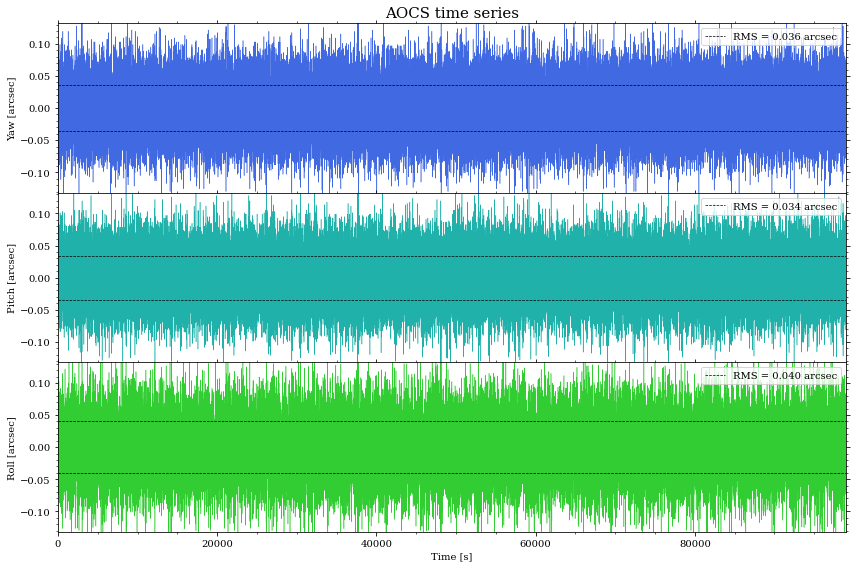

In [54]:
fig = plt.figure(figsize=(12,8))
plotYawPitchRollTimeSeries(fig, df['t'].to_numpy(), df1, ['s', 'arcsec'], 'AOCS time series')
plt.show()

AttributeError: module 'platosim.noise' has no attribute 'powerDensityFFT'

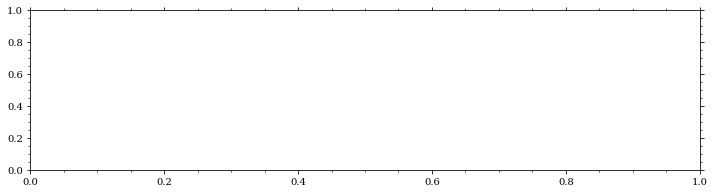

In [60]:
fig = plt.figure(figsize=(12,10))
plotYawPitchRollPSD(fig, time, signals, labels=['s', 'arcsec'], title='AOCS time series')
plt.show()

1.25e-07

### Pointing Reproducibility Error (PRE)

In [9]:
# Coordinates
ICRS = np.array([ra, dec, rot])

# Pointing Reproducibility Error (PRE) in P/L reference frame (yaw, pitch, roll)
t = 3.0/3600
b = 6.0/3600

# Find distribution within 3 sigma of req.
tt = np.array([np.random.normal(0, t/sigma) for i in range(len(quarters))])
bb = np.array([np.random.normal(0, b/sigma) for i in range(len(quarters))])

# Corresponding yaw, pitch, roll
y = tt
z = 3 * y
x = bb - z

# ICRS pointing angles
phi   = np.deg2rad(ra)
theta = np.deg2rad(dec)

# Find change to pointing for quarters
coor = np.zeros((len(quarters), 4))
for i in range(len(quarters)):
    data = changeOfPointing(x[i], y[i], z[i], phi, theta)[0]
    coor[i,:] = np.append(quarters[i], data)

# Save file with relative pointing errors [deg]
np.savetxt(f'{outdir}/PRE.txt', coor, fmt=['%i', '%0.8f', '%0.8f', '%0.8f'])

# Print generated values
print('Yaw, Pitch, and Roll angles')
print(x)
print(y)
print(z)
print('\nChange of coordinates [arcsec]')
print(coor*3600)
print('\nNew coordinates [deg]')
for i in range(len(quarters)):
    print(coor[i][1]+ra, coor[i][2]+dec, coor[i][3])

Yaw, Pitch, and Roll angles
[-0.00084867 -0.00086815  0.00064598  0.00042537  0.00029854 -0.00027058
 -0.00111807  0.00045418]
[ 7.58453871e-05  3.37550316e-04 -3.01467701e-04 -1.30280833e-04
 -7.75953394e-05  2.83531688e-05  1.40615464e-04 -1.47260309e-04]
[ 2.27536161e-04  1.01265095e-03 -9.04403103e-04 -3.90842498e-04
 -2.32786018e-04  8.50595063e-05  4.21846393e-04 -4.41780926e-04]

Change of coordinates [arcsec]
[[ 3.60000000e+03  8.65268850e-01  3.02208570e+00  2.21993679e+00]
 [ 7.20000000e+03  3.85088381e+00  2.97791129e+00  2.30873124e+00]
 [ 1.08000000e+04 -3.43924161e+00 -2.19387238e+00 -1.72523054e+00]
 [ 1.44000000e+04 -1.48628612e+00 -1.47441798e+00 -1.12609641e+00]
 [ 1.80000000e+04 -8.85232875e-01 -1.04084729e+00 -7.88322426e-01]
 [ 2.16000000e+04  3.23462173e-01  9.61690281e-01  7.08375581e-01]
 [ 2.52000000e+04  1.60418696e+00  3.96364153e+00  2.93055550e+00]
 [ 2.88000000e+04 -1.67999351e+00 -1.57074075e+00 -1.20357024e+00]]

New coordinates [deg]
86.79894543245828 -

## Camera alignment errors in yaw, pitch, and roll (x, y, z)

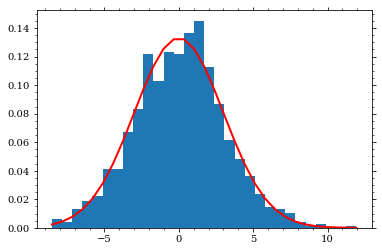

Alt, Az, Yaw, Pitch, and Roll alignment error for all 24 N-CAMs [arcmin]
[[ -0.29361244  -4.41875258  -3.53791527  -0.29361244  -0.88083731]
 [  0.83300367  -0.49115321  -2.99016423   0.83300367   2.49901102]
 [  0.77120358  -0.72219607  -3.03580682   0.77120358   2.31361075]
 [ -1.87849294  -5.24957598   0.38590284  -1.87849294  -5.63547882]
 [ -2.66855492   3.50499971  11.51066447  -2.66855492  -8.00566476]
 [ -0.47756674  -1.68305646  -0.25035623  -0.47756674  -1.43270023]
 [ -1.51817617  -1.38911803   3.16541049  -1.51817617  -4.55452852]
 [  0.09207114   2.69127135   2.41505792   0.09207114   0.27621343]
 [ -0.39958654  -7.83414114  -6.63538151  -0.39958654  -1.19875963]
 [ -0.74567177  -0.60551632   1.63149899  -0.74567177  -2.23701531]
 [ -1.32435458  -0.75514114   3.2179226   -1.32435458  -3.97306374]
 [ -0.4039384   -4.01598257  -2.80416737  -0.4039384   -1.2118152 ]
 [  2.58875847  -2.46577531 -10.23205073   2.58875847   7.76627542]
 [  2.19000962  -0.88329036  -7.45331923   

In [10]:
# Pointing Reproducibility Error (PRE) in P/L reference frame (yaw, pitch, roll)
t = 4.5/60  # [deg]
b = 9.0/60  # [deg]

# Find distribution within 3 sigma of req.
tt = np.array([np.random.normal(0, t/sigma) for i in range(24)])
bb = np.array([np.random.normal(0, b/sigma) for i in range(24)])

# Corresponding yaw, pitch, roll
dy = tt
dz = 3 * dy
dx = bb - dz
mu, sigma = 0, sigma # mean and standard deviation
s = np.random.normal(mu, sigma, 1000)
count, bins, ignored = plt.hist(s, 30, density=True)
plt.plot(bins, 1/(sigma * np.sqrt(2 * np.pi)) * 
         np.exp( - (bins - mu)**2 / (2 * sigma**2) ),
         linewidth=2, color='r')
plt.show()

# Save APE camera misalignments
np.savetxt('APE.txt', np.transpose([tt, bb]), fmt='%.8f')

# Print generate values
print('Alt, Az, Yaw, Pitch, and Roll alignment error for all 24 N-CAMs [arcmin]')
print(np.transpose([tt, bb, dx, dy, dz])*60)